# Composite Mosaic

This notebook is a walkthrough on how to manually create multi-region composite images using the functions provided in the project. To execute the notebook, you first have to download the associated data. To do so, first install the package following the instructions in the `README.md` and then run:

```sh
uv run wildfire-composer refresh
uv run wildfire-composer render EMSR873 EMSR875 EMSR890 EMSR892
```

Now you are ready to go!

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

import xarray as xr

from wildfire_composer.viz import mosaic

In [73]:
raster_path = Path("../data/rasters")

activations = {}
activations["EMSR873"] = {"country": "Italy".capitalize(), "region": "Pisa"}
activations["EMSR875"] = {"country": "Germany".capitalize(), "region": "Bavaria"}
activations["EMSR890"] = {"country": "France".capitalize(), "region": "Diois"}
activations["EMSR892"] = {"country": "Spain".capitalize(), "region": "Andalusia"}

In [74]:
rasters = []
titles = []
subtitles = []

for code, activation in activations.items():
    raster_filepath = raster_path / f"raster_{code}.zarr"
    _da = xr.open_dataarray(raster_filepath, engine="zarr")
    rasters.append(_da.sel(band=["swir16", "nir", "red"], time="post"))
    titles.append(activation["country"])
    subtitles.append(activation["region"])

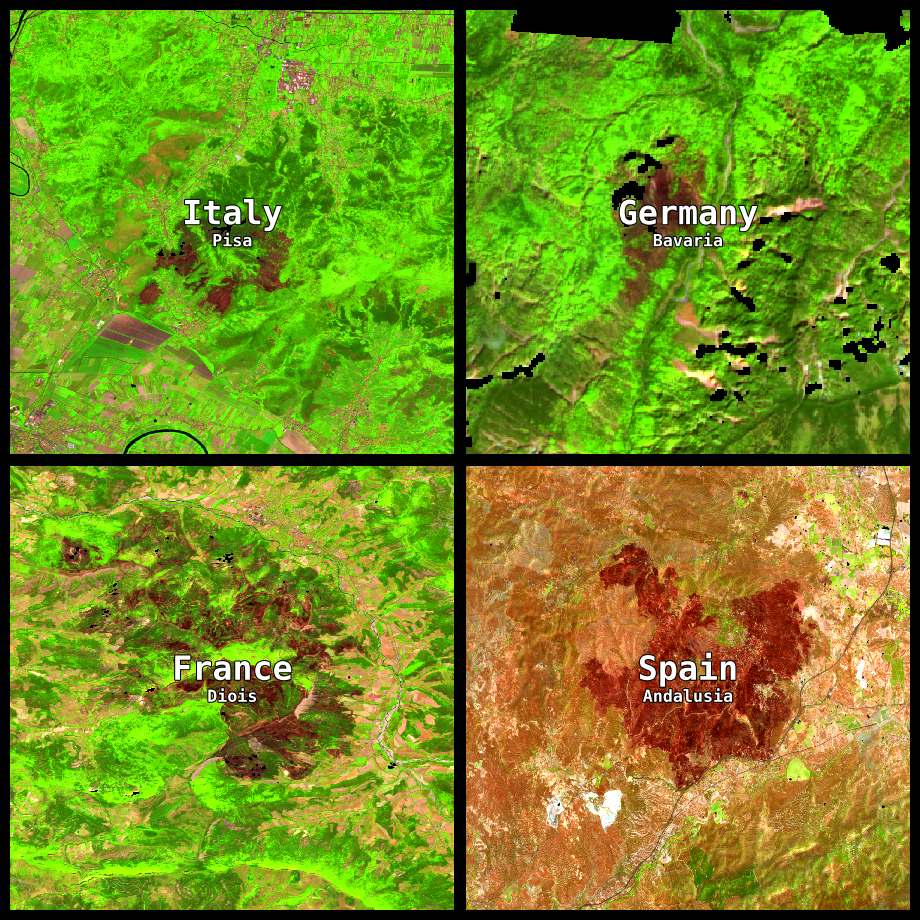

In [75]:
fig = mosaic(rasters, titles, subtitles)

In [76]:
imgs_path = Path("../data/images")
fig.savefig(
    imgs_path / f"wildfire_mosaic.png", dpi=200, bbox_inches="tight", pad_inches=0.1
)